# EMA Results Analysis
This notebook loads and analyzes EMA-formatted results from Vensim sensitivity analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import sys
import itertools
sys.path.append(r'..\3_Conversion_to_EMA')

# EMA Workbench
from ema_workbench.analysis import feature_scoring
from ema_workbench.analysis import prim
from ema_workbench.analysis import parcoords
from ema_workbench.analysis import dimensional_stacking
from ema_workbench.analysis.scenario_discovery_util import RuleInductionType
from ema_workbench.em_framework.salib_samplers import get_SALib_problem

# Sobol Analysis
from SALib.analyze import sobol

## Load EMA Results
Load the converted EMA results from the output directory.

In [2]:
# Load all results from the directory using the custom loader
import vensim_output_to_ema
importlib.reload(vensim_output_to_ema)
from vensim_output_to_ema import load_vensim_ema_results

# Load LHS results for all three scenarios
scenarios = {
    'Reference': r"..\4_Exploratory_Analysis\LHC_Reference_EMA",
    'Optimistic': r"..\4_Exploratory_Analysis\LHC_Optimistic_EMA",
    'Pessimistic': r"..\4_Exploratory_Analysis\LHC_Pessimistic_EMA"
}

lhs_data = {}
for scenario_name, results_dir in scenarios.items():
    experiments_df, outcomes_dict = load_vensim_ema_results(results_dir)
    lhs_data[scenario_name] = {
        'experiments': experiments_df,
        'outcomes': outcomes_dict
    }
    print(f"\n{scenario_name} Scenario:")
    print(f"  Experiments shape: {experiments_df.shape}")
    print(f"  Number of outcomes: {len(outcomes_dict)}")


# Get outcome names (targets) from LHS data
outcome_names = list(lhs_data['Reference']['outcomes'].keys())
print(f"\nOutcome variables (targets): {len(outcome_names)}")
for i, name in enumerate(outcome_names, 1):
    print(f"  {i}. {name}")

Loaded experiments: (10000, 36)
Loaded outcome 'Mean Species Abundance': (10000, 201)
Loaded outcome 'Commercial N application for agriculture': (10000, 201)
Loaded outcome 'Prevalence of Undernourishment': (10000, 201)
Loaded outcome 'Total Agricultural Land Demand': (10000, 201)
Loaded outcome 'Total Freshwater Withdrawal for Food': (10000, 201)
Loaded outcome 'Total GHG Emissions from AFOLU': (10000, 201)

Total outcomes loaded: 6

Reference Scenario:
  Experiments shape: (10000, 36)
  Number of outcomes: 6
Loaded experiments: (10000, 36)
Loaded outcome 'Mean Species Abundance': (10000, 201)
Loaded outcome 'Commercial N application for agriculture': (10000, 201)
Loaded outcome 'Prevalence of Undernourishment': (10000, 201)
Loaded outcome 'Total Agricultural Land Demand': (10000, 201)
Loaded outcome 'Total Freshwater Withdrawal for Food': (10000, 201)
Loaded outcome 'Total GHG Emissions from AFOLU': (10000, 201)

Total outcomes loaded: 6

Optimistic Scenario:
  Experiments shape: (10

# Envelope Graphs: Base Cases and Uncertainty Ranges
Visualize the base case trajectories alongside the envelope of possible outcomes from LHS sampling across all three scenarios (Reference, Optimistic, Pessimistic) for all six target variables.

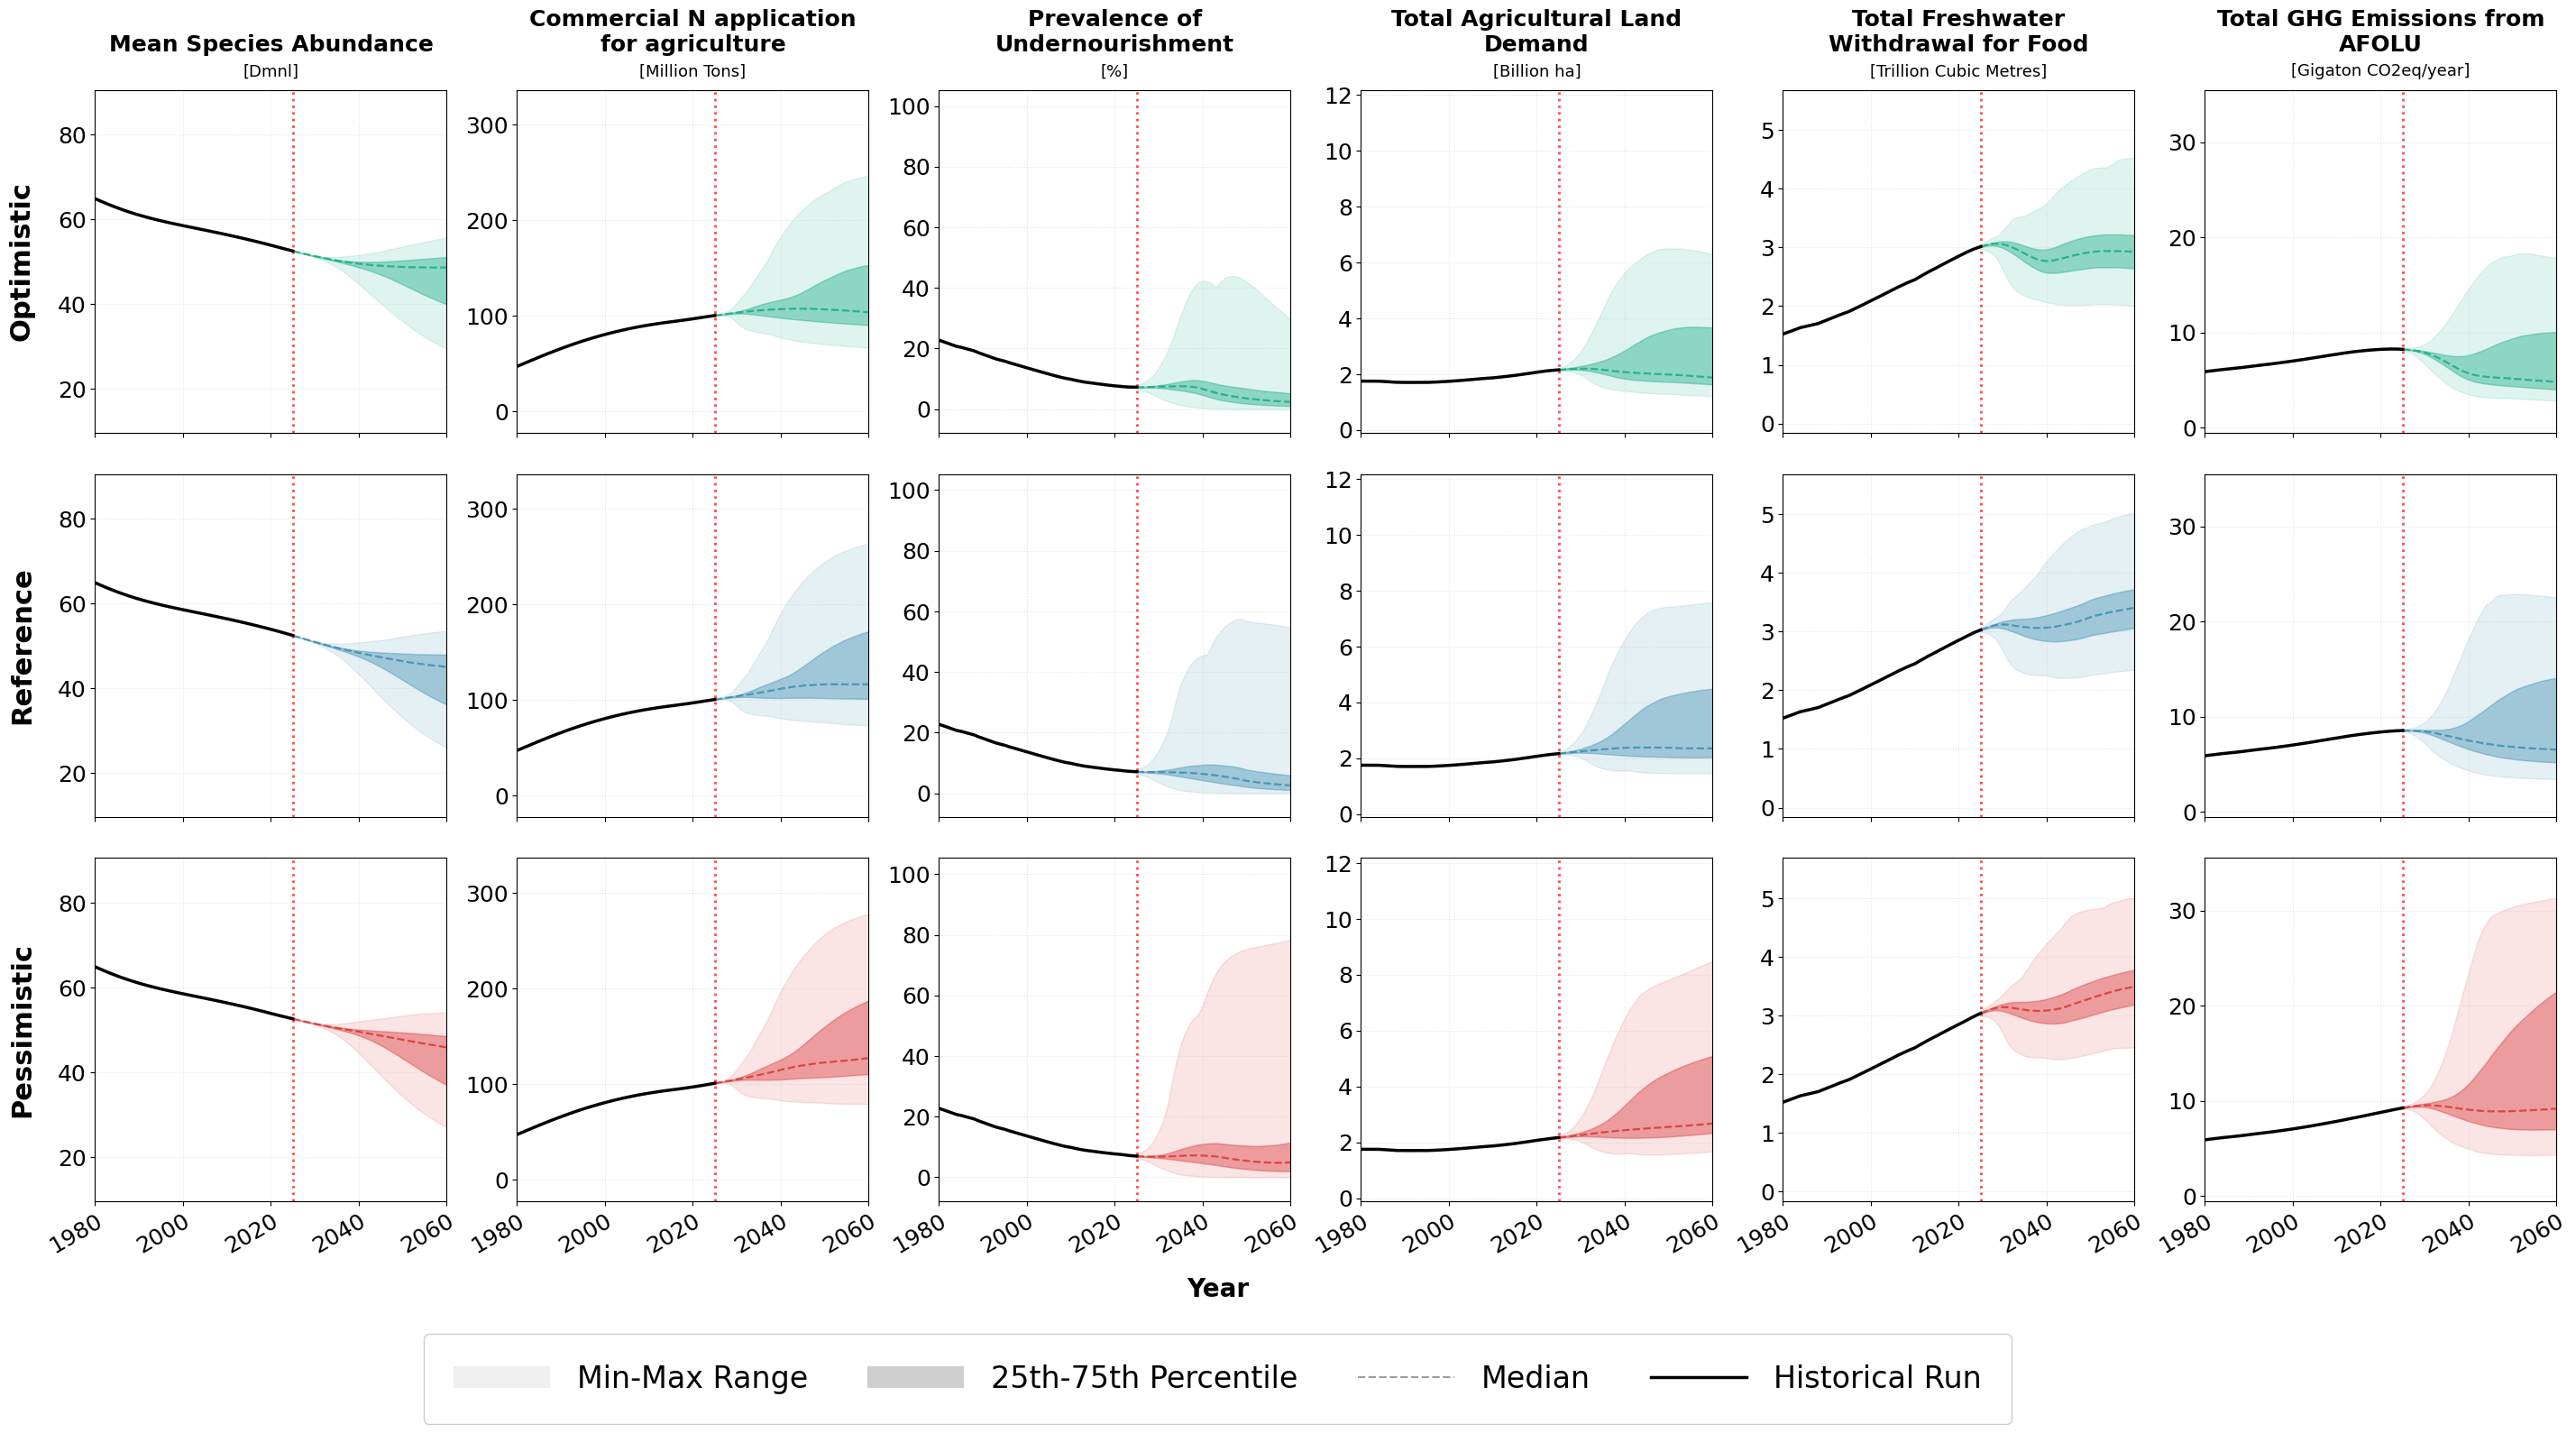

Saved figure to: C:\Users\tanryan\Desktop\FeliXSim_Figures\Final_Figures\f03.png


In [3]:
# Create 3x6 envelope plots: 3 scenarios (rows) x 6 targets (columns)
fig, axes = plt.subplots(3, 6, figsize=(30, 16))
fig.subplots_adjust(left=0.085, right=0.995, top=0.90, bottom=0.13, hspace=0.12, wspace=0.20)

# Publication-ready typography controls
SUBPLOT_TITLE_SIZE = 18
UNIT_LABEL_SIZE = 13
ROW_LABEL_SIZE = 22
X_LABEL_SIZE = 20
Y_LABEL_SIZE = 20
TICK_LABEL_SIZE = 18
LEGEND_SIZE = 24
LINE_WIDTH = 2.5
PCT_FILL_ALPHA = 0.38
RANGE_FILL_ALPHA = 0.12

import textwrap
from pathlib import Path

scenario_order = ['Optimistic', 'Reference', 'Pessimistic']
colors = {'Reference': '#2E86AB', 'Optimistic': '#06A77D', 'Pessimistic': '#D62828'}

# Get outcome names directly from loaded data (in case it was redefined elsewhere)
envelope_outcome_names = list(lhs_data['Reference']['outcomes'].keys())

# Unit labels for each outcome
unit_labels = {
    'Mean Species Abundance': 'Dmnl',
    'Commercial N application for agriculture': 'Million Tons',
    'Prevalence of Undernourishment': '%',
    'Total Agricultural Land Demand': 'Billion ha',
    'Total Freshwater Withdrawal for Food': 'Trillion Cubic Metres',
    'Total GHG Emissions from AFOLU': 'Gigaton CO2eq/year'
}

# Convert model-native values into the units shown in the plot titles
unit_scale = {
    'Mean Species Abundance': 1.0,
    'Commercial N application for agriculture': 1e-6,
    'Prevalence of Undernourishment': 100.0,
    'Total Agricultural Land Demand': 1e-9,
    'Total Freshwater Withdrawal for Food': 1e-3,
    'Total GHG Emissions from AFOLU': 1e-9
}

# Precompute shared y-limits for each outcome so the rows are comparable
shared_y_limits = {}
for outcome_name in envelope_outcome_names:
    scale = unit_scale.get(outcome_name, 1.0)
    all_values = []
    for scenario_name in scenario_order:
        outcome_data = lhs_data[scenario_name]['outcomes'][outcome_name]
        all_values.append((outcome_data.to_numpy().ravel()) * scale)
    stacked_values = np.concatenate(all_values)
    stacked_values = stacked_values[np.isfinite(stacked_values)]
    y_min = stacked_values.min()
    y_max = stacked_values.max()
    y_pad = (y_max - y_min) * 0.08 if y_max > y_min else max(abs(y_max) * 0.05, 1.0)
    shared_y_limits[outcome_name] = (y_min - y_pad, y_max + y_pad)

# Iterate through each scenario (row) and outcome (column)
for row_idx, scenario_name in enumerate(scenario_order):
    for col_idx, outcome_name in enumerate(envelope_outcome_names):
        ax = axes[row_idx, col_idx]
        scale = unit_scale.get(outcome_name, 1.0)
        
        # Get the LHS outcome data (all experiments)
        outcome_data = lhs_data[scenario_name]['outcomes'][outcome_name]
        outcome_data_scaled = outcome_data * scale
        
        # Get time steps (columns are time steps) and convert to years (1900-2100)
        time_steps_all = outcome_data_scaled.columns.astype(float) + 1900
        
        # Filter envelope data to only include years >= 2025
        mask_2025 = time_steps_all >= 2025
        time_steps = time_steps_all[mask_2025]
        outcome_data_filtered = outcome_data_scaled.iloc[:, mask_2025]
        
        # Calculate envelope (min, max, median, percentiles) for filtered data (2025-2100)
        envelope_min = outcome_data_filtered.min(axis=0)
        envelope_max = outcome_data_filtered.max(axis=0)
        envelope_median = outcome_data_filtered.median(axis=0)
        envelope_25 = outcome_data_filtered.quantile(0.25, axis=0)
        envelope_75 = outcome_data_filtered.quantile(0.75, axis=0)
        
        # Plot envelope ranges (2025-2100 only)
        ax.fill_between(time_steps, envelope_min, envelope_max, 
                        alpha=RANGE_FILL_ALPHA, color=colors[scenario_name], label='Min-Max Range')
        ax.fill_between(time_steps, envelope_25, envelope_75, 
                        alpha=PCT_FILL_ALPHA, color=colors[scenario_name], label='25th-75th Percentile')
        ax.plot(time_steps, envelope_median, color=colors[scenario_name], 
               linewidth=1.6, linestyle='--', alpha=0.75, label='Median')
        
        # Plot the scenario-specific historical run for the historical period (1950-2025)
        if outcome_name in lhs_data[scenario_name]['outcomes']:
            scenario_data = lhs_data[scenario_name]['outcomes'][outcome_name] * scale
            scenario_time_steps = scenario_data.columns.astype(float) + 1900
            historical_mask = (scenario_time_steps >= 1950) & (scenario_time_steps <= 2025)
            historical_time = scenario_time_steps[historical_mask]
            historical_values = scenario_data.iloc[:, historical_mask].median(axis=0)
            
            if len(historical_time) > 0:
                ax.plot(historical_time, historical_values, color='black', 
                       linewidth=LINE_WIDTH, label='Historical run', zorder=10)
        
        # Add vertical line at year 2025
        ax.axvline(x=2025, color='red', linestyle=':', linewidth=2, alpha=0.7, zorder=5)
        
        # Formatting
        ax.grid(True, alpha=0.3, linestyle=':')
        ax.set_xlim(1980, 2060)
        ax.set_ylim(shared_y_limits[outcome_name])
        ax.ticklabel_format(axis='y', style='plain', useOffset=False)
        ax.yaxis.get_offset_text().set_visible(False)
        
        # Increase tick label sizes
        ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
        ax.tick_params(axis='x', labelbottom=(row_idx == len(scenario_order) - 1))
        
        # Add titles and labels with larger font sizes
        if row_idx == 0:
            wrapped_name = textwrap.fill(outcome_name, width=24)
            unit_text = unit_labels.get(outcome_name, '')
            ax.text(0.5, 1.10, wrapped_name, transform=ax.transAxes, ha='center', va='bottom', fontsize=SUBPLOT_TITLE_SIZE, fontweight='bold')
            ax.text(0.5, 1.03, f"[{unit_text}]", transform=ax.transAxes, ha='center', va='bottom', fontsize=UNIT_LABEL_SIZE, fontweight='normal')
        if col_idx == 0:
            ax.set_ylabel(scenario_name, fontsize=ROW_LABEL_SIZE, fontweight='bold', labelpad=18)
        if row_idx == len(scenario_order) - 1:
            ax.set_xlabel('')
            for tick in ax.get_xticklabels():
                tick.set_rotation(30)
                tick.set_horizontalalignment('right')
                tick.set_rotation_mode('anchor')
        else:
            ax.set_xlabel('')

# Create figure-level legend at the bottom with grey colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='grey', alpha=RANGE_FILL_ALPHA, label='Min-Max Range'),
    Patch(facecolor='grey', alpha=PCT_FILL_ALPHA, label='25th-75th Percentile'),
    Line2D([0], [0], color='grey', linewidth=1.6, linestyle='--', alpha=0.75, label='Median'),
    Line2D([0], [0], color='black', linewidth=LINE_WIDTH, label='Historical Run')
]

fig.supxlabel('Year', fontsize=X_LABEL_SIZE, fontweight='bold', y=0.06)
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.035), 
          ncol=4, fontsize=LEGEND_SIZE, framealpha=0.98, fancybox=True, handlelength=3.2, borderpad=1.0, labelspacing=1.0, handletextpad=0.9)

# Export publication-quality figure
output_dir = Path("..") / ".." / "Final_Figures"
output_dir.mkdir(parents=True, exist_ok=True)

fig_path = output_dir / "f03.png"
fig.savefig(
    fig_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
print(f"Saved figure to: {fig_path.resolve()}")


In [4]:
# Review

# Inspect extreme high prevalence of undernourishment cases and the inputs that produced them
# This uses the scenario-specific experiment tables and outcome series from lhs_data.
reference_outcome = 'Prevalence of Undernourishment'
top_n = 5
print(f"\nTop {top_n} extreme-high {reference_outcome} cases by scenario (final timestep):")
for scenario_name in ['Reference', 'Optimistic', 'Pessimistic']:
    scenario_experiments = lhs_data[scenario_name]['experiments'].copy()
    scenario_outcomes = lhs_data[scenario_name]['outcomes'][reference_outcome]

    if reference_outcome not in lhs_data[scenario_name]['outcomes']:
        print(f"\n{scenario_name}: outcome not available")
        continue

    final_poverty = scenario_outcomes.iloc[:, -1].copy()
    ranking = final_poverty.sort_values(ascending=False).head(top_n)
    ranked_index = ranking.index

    print(f"\n{scenario_name} scenario")
    for rank, experiment_idx in enumerate(ranked_index, start=1):
        input_row = scenario_experiments.loc[experiment_idx].copy()
        value = ranking.loc[experiment_idx]
        print(f"  {rank}. experiment {experiment_idx} -> {reference_outcome} final value = {value:.4f}")
        print("     inputs:")
        for column_name, column_value in input_row.items():
            print(f"       {column_name}: {column_value}")

# Optional compact summary table for quick comparison
summary_rows = []
for scenario_name in ['Reference', 'Optimistic', 'Pessimistic']:
    scenario_experiments = lhs_data[scenario_name]['experiments'].copy()
    scenario_outcomes = lhs_data[scenario_name]['outcomes'][reference_outcome]
    top_index = scenario_outcomes.iloc[:, -1].idxmax()
    summary_rows.append({
        'scenario': scenario_name,
        'experiment_index': top_index,
        reference_outcome: scenario_outcomes.iloc[top_index, -1],
    })

summary_df = pd.DataFrame(summary_rows)
print('\nHighest final prevalence of undernourishment by scenario:')
print(summary_df.to_string(index=False))



Top 5 extreme-high Prevalence of Undernourishment cases by scenario (final timestep):

Reference scenario
  1. experiment 605 -> Prevalence of Undernourishment final value = 0.4412
     inputs:
       Custom scenario market share of alternative proteins[AltPasMeat]: 17.934557616629522
       Custom scenario market share of alternative proteins[AltCropMeat]: 15.585241342275989
       Custom scenario market share of alternative proteins[AltDairy]: 97.43097923246096
       Custom scenario market share of alternative proteins[AltEggs]: 3.77712451269885
       End Year of AP: 2046.0821661976145
       End Year of Feed Switch: 2041.4135850903813
       End Year of Fertiliser: 2042.5780229971808
       End Year of FWL Switch: 2042.6964540177903
       End Year of Global Diet: 2040.3470334113608
       End Year of Yield: 2051.4102414939666
       Feed Switch: 2.0
       Fertiliser Multiplier: 0.9995746365756774
       Fraction of alternative protein types in the market[AltPasMeat,Plant]: 74.1

# Trade-offs (Parallel Axis Plot)

Final-timestep table shape: (10000, 6)
Analyzing 6 outcomes across 10000 experiments


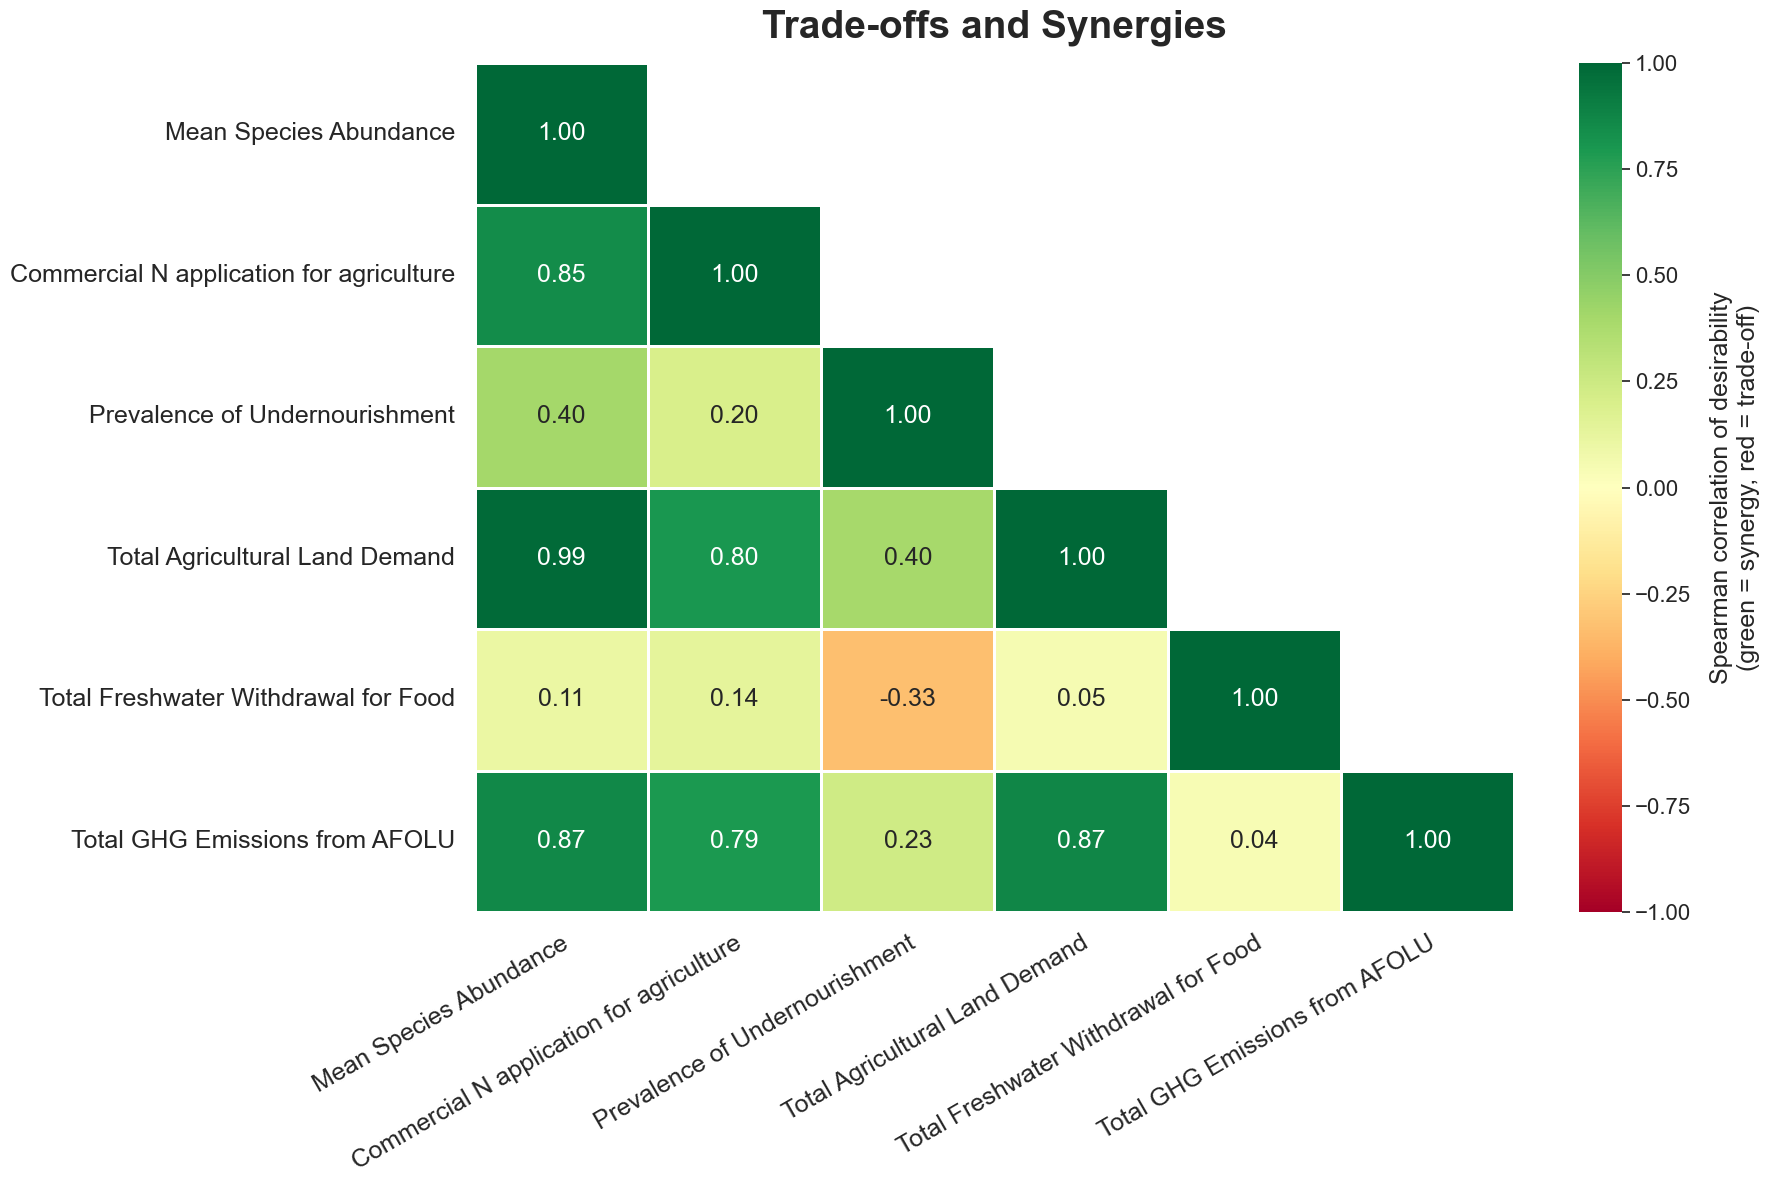


Pairwise outcome matrix now uses desirability scores.
Positive values mean the two outcomes move together in their ideal direction.
Negative values mean a trade-off in ideal-direction terms.
Matrix is based on final-timestep values across all scenarios combined.


In [5]:
# Trade-offs and Synergies (Outcome Pair Matrix)
import matplotlib.colors as mcolors

# Select outcomes for trade-off analysis (final timestep values)
outcome_names = list(outcomes_dict.keys())

# Build a single long table of final-timestep outcome values across all runs
scenario_col = experiments_df['scenario'].astype(str).str.strip().str.lower() if 'scenario' in experiments_df.columns else pd.Series(['scenario'] * len(experiments_df))
scenario_map = {
    'optimistic': 'Optimistic',
    'reference': 'Reference',
    'pessimistic': 'Pessimistic',
}
scenario_labels = scenario_col.map(lambda value: scenario_map.get(str(value).strip().lower(), str(value)))

final_df = pd.DataFrame(index=experiments_df.index)
for outcome_name in outcome_names:
    final_df[outcome_name] = outcomes_dict[outcome_name].iloc[:, -1].values

print(f'Final-timestep table shape: {final_df.shape}')
print(f'Analyzing {len(outcome_names)} outcomes across {len(final_df)} experiments')

# Convert outcomes into desirability scores so positive correlation means jointly more ideal
# Higher-is-better outcome: keep as-is; lower-is-better outcomes: multiply by -1
ideal_direction = {
    'Mean Species Abundance': 1,
    'Commercial N application for agriculture': -1,
    'Prevalence of Undernourishment': -1,
    'Total Agricultural Land Demand': -1,
    'Total Freshwater Withdrawal for Food': -1,
    'Total GHG Emissions from AFOLU': -1,
}

desirability_df = final_df.copy()
for outcome_name in outcome_names:
    desirability_df[outcome_name] = final_df[outcome_name] * ideal_direction.get(outcome_name, 1)

# Correlate the desirability scores across runs
correlation_df = desirability_df.corr(method='spearman')

# Mask the redundant lower triangle since the matrix is symmetric
mask = np.triu(np.ones_like(correlation_df, dtype=bool), k=1)

sns.set_theme(style='white')
plt.figure(figsize=(18, 12))
ax = sns.heatmap(
    correlation_df,
    mask=mask,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 18},
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Spearman correlation of desirability (green = synergy, red = trade-off)'}
)

ax.set_title('Trade-offs and Synergies', fontsize=28, fontweight='bold', pad=18)
ax.set_xlabel('', fontsize=22, labelpad=14)
ax.set_ylabel('', fontsize=22, labelpad=14)
ax.tick_params(axis='x', labelrotation=30, labelsize=18, pad=8)
ax.tick_params(axis='y', labelrotation=0, labelsize=18, pad=8)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment('right')
    tick.set_rotation_mode('anchor')
for tick in ax.get_yticklabels():
    tick.set_verticalalignment('center')

colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=16)
colorbar.set_label('Spearman correlation of desirability\n(green = synergy, red = trade-off)', fontsize=18, labelpad=14)

plt.tight_layout()
plt.show()

print('\nPairwise outcome matrix now uses desirability scores.')
print('Positive values mean the two outcomes move together in their ideal direction.')
print('Negative values mean a trade-off in ideal-direction terms.')
print('Matrix is based on final-timestep values across all scenarios combined.')
